In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler

ton_iot_path    = r"C:\Users\sruja\SEM 6\Mini_Project\data\TON_IOT\train_test_network.csv"
cic_folder_path = r"C:\Users\sruja\SEM 6\Mini_Project\data\CIC-IDS-2017"
output_path     = r"C:\Users\sruja\SEM 6\Mini_Project\data\Processed"
graph_path      = r"C:\Users\sruja\SEM 6\Mini_Project\data\Graphs"

In [2]:
print("Checking folders...")
print("Main data folder:  ", os.listdir(r"C:\Users\sruja\SEM 6\Mini_Project\data"))
print("TON_IoT folder:    ", os.listdir(r"C:\Users\sruja\SEM 6\Mini_Project\data\TON_IOT"))
print("CIC folder:        ", os.listdir(cic_folder_path))

Checking folders...
Main data folder:   ['CIC-IDS-2017', 'Graphs', 'Processed', 'TON_IOT']
TON_IoT folder:     ['train_test_network.csv']
CIC folder:         ['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


In [3]:
print("Loading TON-IoT dataset...")
ton_df = pd.read_csv(ton_iot_path, low_memory=False)
print("TON-IoT shape:", ton_df.shape)
print("TON-IoT columns:", ton_df.columns.tolist())
print("\ntype column value counts (BEFORE processing):")
print(ton_df['type'].value_counts())
print("\nlabel column value counts (BEFORE processing):")
print(ton_df['label'].value_counts())

Loading TON-IoT dataset...
TON-IoT shape: (211043, 44)
TON-IoT columns: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']

type column value counts (BEFORE processing):
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
ransomware    20000
scanning      20000
xss           20000
mitm           1043
Name: count, dtype: int64

label c

In [4]:
print("Loading CIC dataset...")
cic_files = [f for f in os.listdir(cic_folder_path) if f.endswith(".csv")]
cic_list  = []

for file in cic_files:
    file_path = os.path.join(cic_folder_path, file)
    print(f"  Reading {file}")
    try:
        df = pd.read_csv(file_path, low_memory=False)
        cic_list.append(df)
    except Exception as e:
        print(f"  Error reading {file}: {e}")

cic_df = pd.concat(cic_list, ignore_index=True)
cic_df.columns = cic_df.columns.str.strip()   # remove leading/trailing spaces

print(f"\nCIC dataset merged! Shape: {cic_df.shape}")
print("\nLabel column value counts (BEFORE processing):")
print(cic_df['Label'].value_counts())

Loading CIC dataset...
  Reading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Reading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Reading Friday-WorkingHours-Morning.pcap_ISCX.csv
  Reading Monday-WorkingHours.pcap_ISCX.csv
  Reading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Reading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Reading Tuesday-WorkingHours.pcap_ISCX.csv
  Reading Wednesday-workingHours.pcap_ISCX.csv

CIC dataset merged! Shape: (2830743, 79)

Label column value counts (BEFORE processing):
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS  

In [5]:
def preprocess(df, label_cols_to_skip=None):
    """
    Clean and normalize a dataframe.
    label_cols_to_skip: list of column names to exclude from scaling
                        (they are put back after scaling unchanged)
    """
    print("\nPreprocessing dataset...")

    if label_cols_to_skip is None:
        label_cols_to_skip = []

    # Pull out label columns before any processing
    saved_labels = {}
    for col in label_cols_to_skip:
        if col in df.columns:
            saved_labels[col] = df[col].copy()
            df = df.drop(columns=[col])

    # Remove duplicates
    df = df.drop_duplicates()

    # Handle inf values
    df = df.replace([np.inf, -np.inf], np.nan)

    # Drop rows with missing values
    df = df.dropna()

    # Encode remaining categorical columns (strings → integers)
    for col in df.columns:
        if df[col].dtype == 'object':
            try:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                print(f"  Encoded column: {col}")
            except Exception as e:
                print(f"  Skipping column {col}: {e}")

    # Normalize numeric columns
    num_cols = df.select_dtypes(include=np.number).columns
    scaler   = StandardScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])

    # Put label columns back (unscaled, unencoded)
    for col, values in saved_labels.items():
        # align index after dropna removed rows
        df[col] = values.loc[df.index].values

    print(f"  Final shape: {df.shape}")
    print("Preprocessing done!")
    return df

In [6]:
# TON-IoT: skip 'type' and 'label' from scaling — these are our class labels
print("="*40)
print("Processing TON-IoT...")
ton_processed = preprocess(
    ton_df.copy(),
    label_cols_to_skip=['type', 'label']
)

print("\nTON-IoT type column after processing (should still be original strings/values):")
print(ton_processed['type'].value_counts())

# CIC-IDS: skip 'Label' from scaling
print("\n" + "="*40)
print("Processing CIC-IDS-2017...")
cic_processed = preprocess(
    cic_df.copy(),
    label_cols_to_skip=['Label']
)

print("\nCIC-IDS Label column after processing (should still be original strings/values):")
print(cic_processed['Label'].value_counts())

Processing TON-IoT...

Preprocessing dataset...
  Encoded column: src_ip
  Encoded column: dst_ip
  Encoded column: proto
  Encoded column: service
  Encoded column: conn_state
  Encoded column: dns_query
  Encoded column: dns_AA
  Encoded column: dns_RD
  Encoded column: dns_RA
  Encoded column: dns_rejected
  Encoded column: ssl_version
  Encoded column: ssl_cipher
  Encoded column: ssl_resumed
  Encoded column: ssl_established
  Encoded column: ssl_subject
  Encoded column: ssl_issuer
  Encoded column: http_trans_depth
  Encoded column: http_method
  Encoded column: http_uri
  Encoded column: http_version
  Encoded column: http_user_agent
  Encoded column: http_orig_mime_types
  Encoded column: http_resp_mime_types
  Encoded column: weird_name
  Encoded column: weird_addl
  Encoded column: weird_notice
  Final shape: (190474, 44)
Preprocessing done!

TON-IoT type column after processing (should still be original strings/values):
type
normal        42040
scanning      20000
ddos     

In [7]:
os.makedirs(output_path, exist_ok=True)

ton_processed.to_csv(os.path.join(output_path, "toniot_processed.csv"),   index=False)
cic_processed.to_csv(os.path.join(output_path, "cicids2017_processed.csv"), index=False)

print("✅ Saved:")
print(f"  {output_path}\\toniot_processed.csv     — shape: {ton_processed.shape}")
print(f"  {output_path}\\cicids2017_processed.csv — shape: {cic_processed.shape}")

✅ Saved:
  C:\Users\sruja\SEM 6\Mini_Project\data\Processed\toniot_processed.csv     — shape: (190474, 44)
  C:\Users\sruja\SEM 6\Mini_Project\data\Processed\cicids2017_processed.csv — shape: (2520101, 79)


In [8]:
import torch
import torch_geometric
print("PyTorch version  :", torch.__version__)
print("PyG version      :", torch_geometric.__version__)
print("CUDA available   :", torch.cuda.is_available())

PyTorch version  : 2.7.0+cpu
PyG version      : 2.7.0
CUDA available   : False


In [9]:
exec(open(r"C:\Users\sruja\SEM 6\Mini_Project\graph_construction.py").read())

Loading processed CSVs...
TON-IoT shape : (190474, 44)
CIC-IDS shape : (2520101, 79)

TON-IoT columns : ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'type', 'label']

CIC-IDS columns : ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet 

In [10]:
import torch, os

graph_path = r"C:\Users\sruja\SEM 6\Mini_Project\data\Graphs"

ton = torch.load(os.path.join(graph_path, "toniot_graph.pt"),    weights_only=False)
cic = torch.load(os.path.join(graph_path, "cicids2017_graph.pt"), weights_only=False)

print("TON-IoT graph :", ton)
print("  y dtype      :", ton.y.dtype)
print("  unique labels:", torch.unique(ton.y).tolist())

print("\nCIC-IDS graph :", cic)
print("  y dtype      :", cic.y.dtype)
print("  unique labels:", torch.unique(cic.y).tolist())

# Both should show dtype=torch.int64 and labels like [0, 1, 2, ...]
# If you see float labels here, re-run from Cell 6

TON-IoT graph : Data(x=[804, 40], edge_index=[2, 190474], edge_attr=[190474, 40], y=[190474], num_nodes=804)
  y dtype      : torch.int64
  unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

CIC-IDS graph : Data(x=[100000, 78], edge_index=[2, 500000], edge_attr=[500000, 78], y=[100000], num_nodes=100000)
  y dtype      : torch.int64
  unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


In [5]:
exec(open(r"C:\Users\sruja\SEM 6\Mini_Project\train_gat.py").read())


  DATASET: TON-IoT
Classes: 10 | Node feat dim: 40
Label distribution: {tensor(0): tensor(18711), tensor(1): tensor(19993), tensor(2): tensor(18992), tensor(3): tensor(19964), tensor(4): tensor(1041), tensor(5): tensor(42040), tensor(6): tensor(19861), tensor(7): tensor(14735), tensor(8): tensor(20000), tensor(9): tensor(15137)}
ZERODAY_CLASS = 4
Seen edges: 189433 | Zero-day edges: 1041
Train: 132603 | Val: 28415 | Test seen: 28415 | Test zero-day: 1041
Device: cpu

Training...

Epoch 010 | Train Loss: 2.1048 | Val Loss: 2.1405 | Val Acc: 0.4031
Epoch 020 | Train Loss: 1.9138 | Val Loss: 1.8962 | Val Acc: 0.3780
Epoch 030 | Train Loss: 1.7372 | Val Loss: 1.6624 | Val Acc: 0.4641
Epoch 040 | Train Loss: 1.5356 | Val Loss: 1.4742 | Val Acc: 0.4710
Epoch 050 | Train Loss: 1.3756 | Val Loss: 1.3163 | Val Acc: 0.5869
Epoch 060 | Train Loss: 1.3173 | Val Loss: 1.1751 | Val Acc: 0.6190
Epoch 070 | Train Loss: 1.2879 | Val Loss: 1.0501 | Val Acc: 0.6374
Epoch 080 | Train Loss: 1.0252 | Val L

TON-IoT features: 40
CIC-IDS features: 78

  XAI -- TON-IoT  [gnnexplainer]
  Model loaded | classes=10 | node_feats=40 | edge_feats=40

  Explaining 5 zero-day edges (GNNExplainer 50 epochs)...
    Edge 78463 (zero-day) | class=4 | top: conn_state (0.0018)
    Edge 78116 (zero-day) | class=4 | top: dns_query (0.0042)
    Edge 78340 (zero-day) | class=4 | top: dst_port (0.0044)
    Edge 77752 (zero-day) | class=4 | top: src_pkts (0.0013)
    Edge 78110 (zero-day) | class=4 | top: src_bytes (0.0041)

  Explaining 5 seen edges (GNNExplainer 50 epochs)...
    Edge 185854 (seen) | class=9 | top: dns_qtype (0.0069)
    Edge 17839 (seen) | class=0 | top: src_port (0.0018)
    Edge 100771 (seen) | class=5 | top: proto (0.0082)
    Edge 145225 (seen) | class=7 | top: dns_qclass (0.0054)
    Edge 140416 (seen) | class=6 | top: conn_state (0.0027)

  CSV saved -> C:\Users\sruja\SEM 6\Mini_Project\outputs\xai\ton_iot_explanations.csv

  XAI -- CIC-IDS-2017  [gradient]
  Model loaded | classes=15 

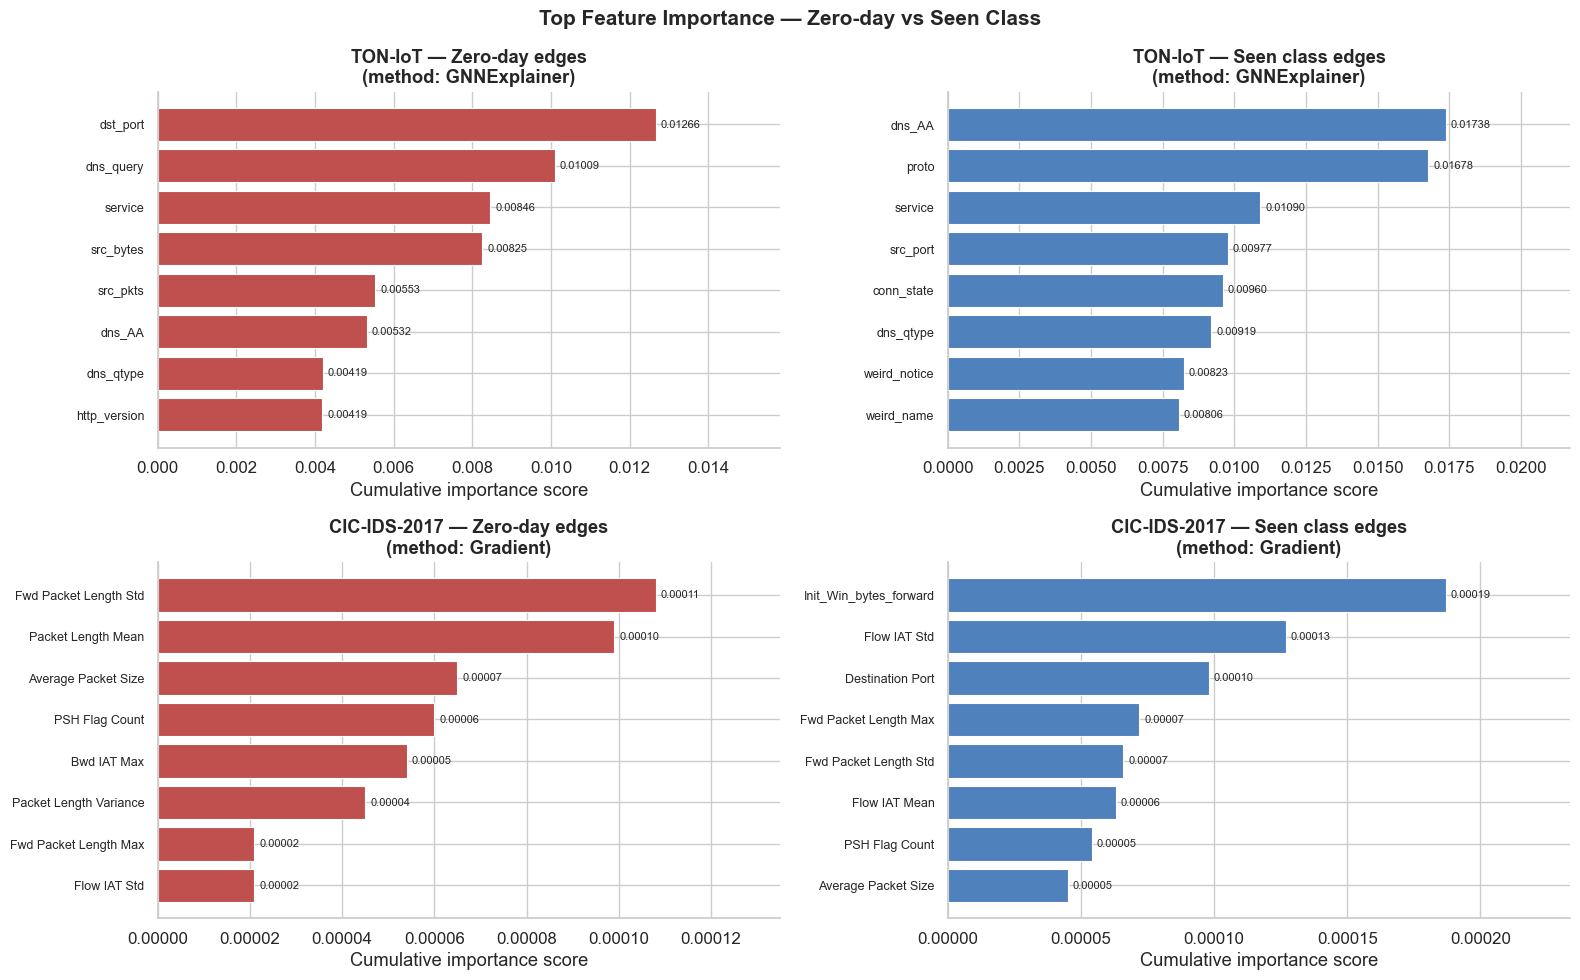

Plot 1 done: Feature importance bar charts


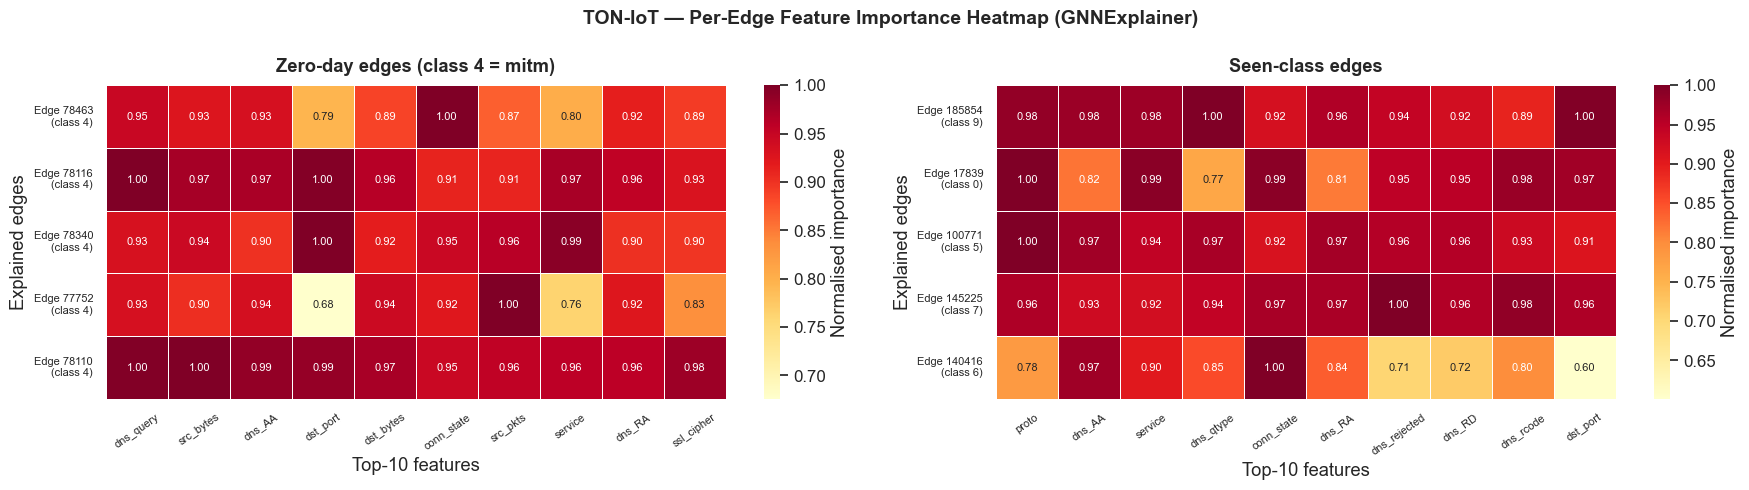

Plot 2 done: TON-IoT heatmap


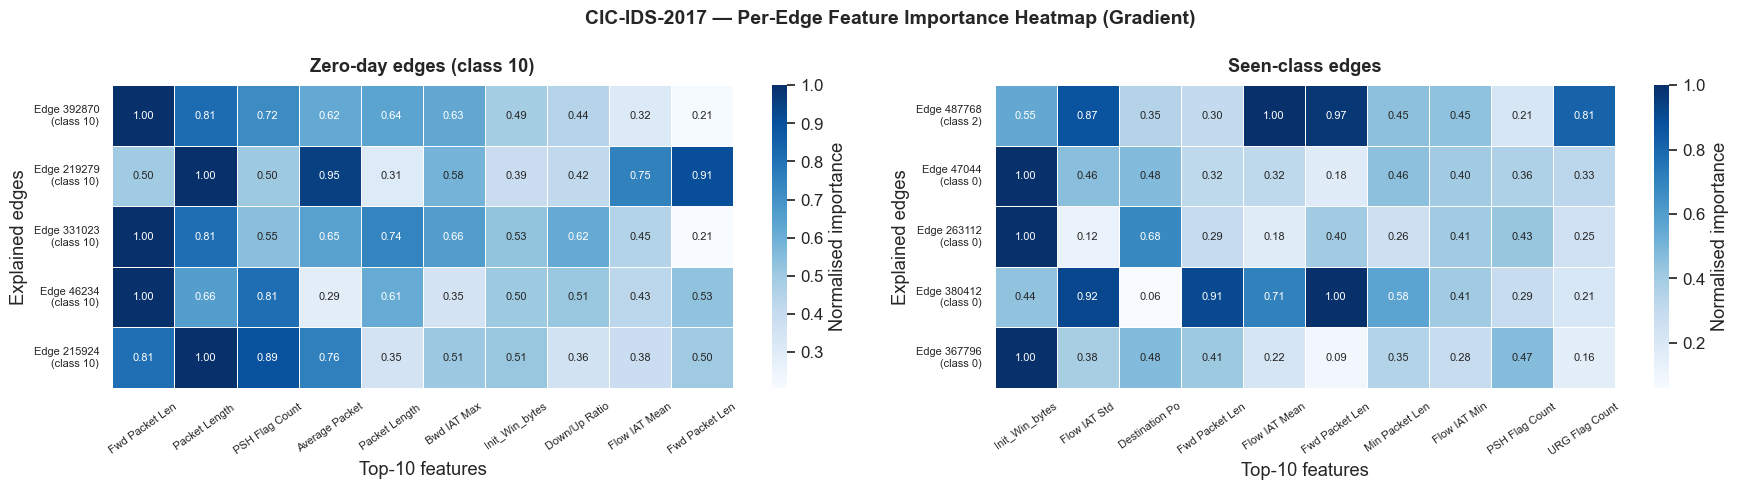

Plot 3 done: CIC-IDS heatmap


<string>:503: FutureWarning: Passing `palette` without assigning `hue` is deprecated.


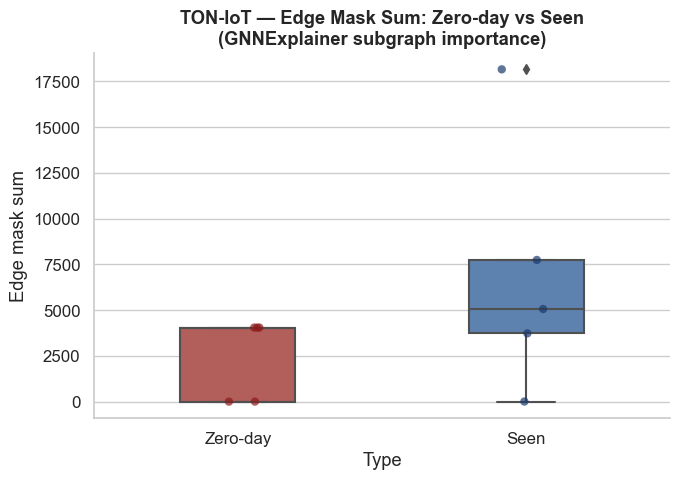

Plot 4 done: Edge mask boxplot


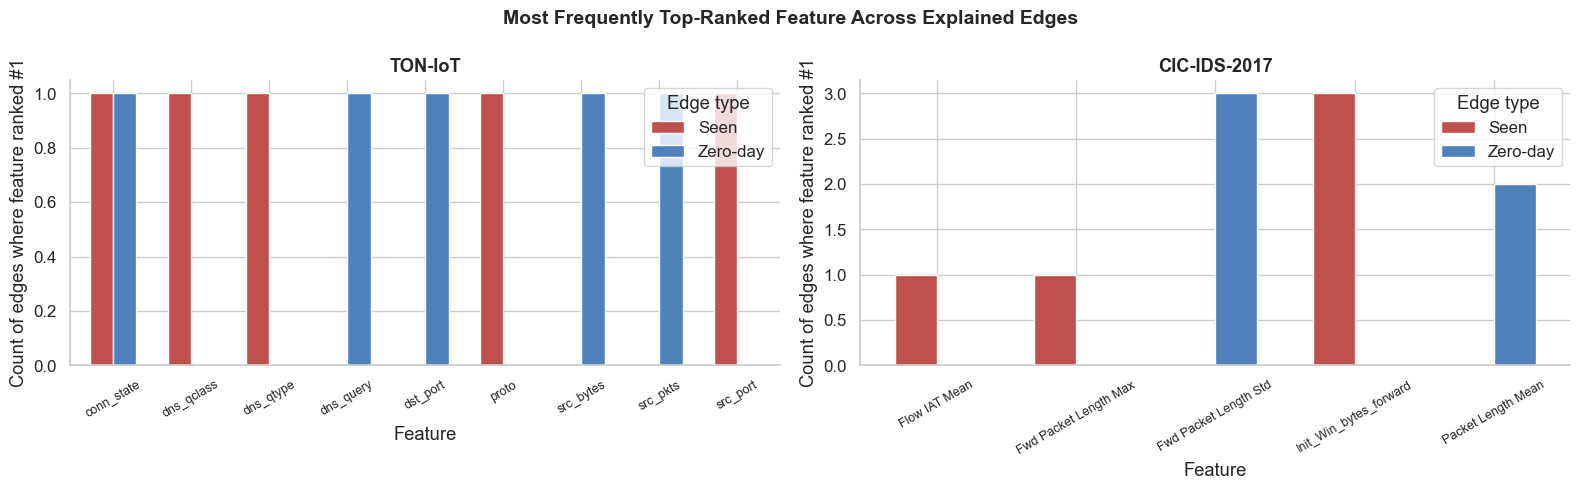

Plot 5 done: Top-1 feature frequency


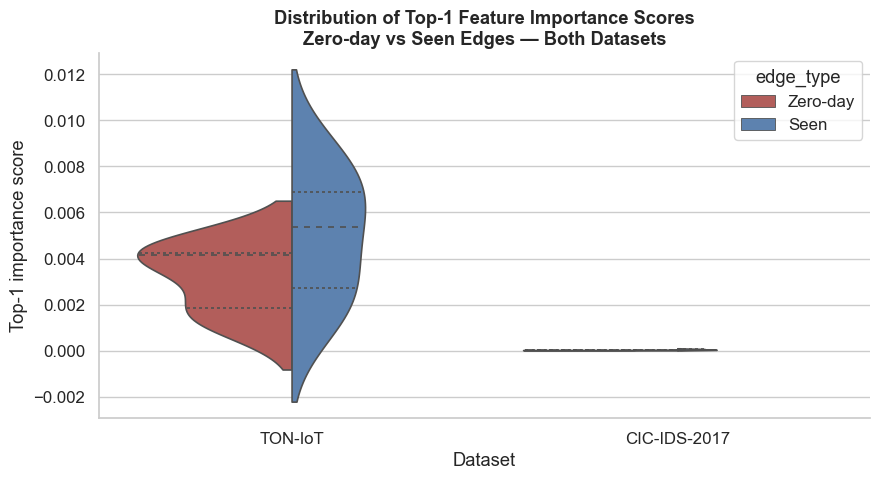

Plot 6 done: Violin plot

PHASE 5 COMPLETE — XAI SUMMARY

TON-IoT  (method: GNNExplainer)
  Zero-day top feature : conn_state
  Seen-class top feature: dns_qtype
  Edges explained: 10 (5 zero-day, 5 seen)

CIC-IDS-2017  (method: Gradient)
  Zero-day top feature : Fwd Packet Length Std
  Seen-class top feature: Init_Win_bytes_forward
  Edges explained: 10 (5 zero-day, 5 seen)

CSVs saved to: C:\Users\sruja\SEM 6\Mini_Project\outputs\xai


In [7]:
exec(open(r"C:\Users\sruja\SEM 6\Mini_Project\xai_phase5.py", encoding='utf-8').read())

In [9]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")   # must be before pyplot import for saving files
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ==============================
# PATHS
# ==============================
output_path = r"C:\Users\sruja\SEM 6\Mini_Project\outputs\xai"
img_path    = os.path.join(output_path, "images")
os.makedirs(img_path, exist_ok=True)

# ==============================
# LOAD CSVs
# ==============================
ton_xai = pd.read_csv(os.path.join(output_path, "ton_iot_explanations.csv"))
cic_xai = pd.read_csv(os.path.join(output_path, "cic_ids_2017_explanations.csv"))

# Fix node_importance column (stored as string in CSV)
import ast
for df in [ton_xai, cic_xai]:
    if "node_importance" in df.columns:
        df["node_importance"] = df["node_importance"].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

ton_feature_names = [c for c in pd.read_csv(
    r"C:\Users\sruja\SEM 6\Mini_Project\data\Processed\toniot_processed.csv",
    nrows=0).columns
    if c not in {"src_ip","dst_ip","type","ts","label"}]

_cic_cols = pd.read_csv(
    r"C:\Users\sruja\SEM 6\Mini_Project\data\Processed\cicids2017_processed.csv",
    nrows=0)
_cic_cols.columns = _cic_cols.columns.str.strip()
cic_feature_names = [c for c in _cic_cols.columns if c != "Label"]

print(f"TON-IoT  rows: {len(ton_xai)} | CIC-IDS rows: {len(cic_xai)}")
print(f"Saving images to: {img_path}")


# ==============================
# HELPER FUNCTIONS
# ==============================
def get_top_features(df, is_zeroday, top_n=8):
    subset = df[df["is_zeroday"] == is_zeroday]
    feat_scores = {}
    for _, row in subset.iterrows():
        for rank in range(1, 6):
            feat  = row.get(f"top{rank}_feature")
            score = row.get(f"top{rank}_score", 0.0)
            if feat:
                feat_scores[feat] = feat_scores.get(feat, 0.0) + float(score)
    if not feat_scores:
        return [], []
    top = sorted(feat_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return [t[0] for t in top], [t[1] for t in top]


def get_per_edge_importance(df, feature_names, is_zeroday, top_n=10):
    subset = df[df["is_zeroday"] == is_zeroday].reset_index(drop=True)
    if subset.empty:
        return None, None, None
    all_imp, edge_labels = [], []
    for _, row in subset.iterrows():
        imp = row.get("node_importance", None)
        if imp is not None and len(imp) > 0:
            all_imp.append(np.array(imp))
            edge_labels.append(
                f"Edge {row['edge_idx']}\n(class {row['true_class']})")
    if not all_imp:
        return None, None, None
    mat          = np.stack(all_imp)
    mean_imp     = mat.mean(axis=0)
    top_feat_idx = np.argsort(mean_imp)[::-1][:top_n]
    feat_labels  = [feature_names[i] if i < len(feature_names)
                    else f"feat_{i}" for i in top_feat_idx]
    return mat[:, top_feat_idx], feat_labels, edge_labels


# ==============================
# PLOT 1 — Feature importance bar charts
# ==============================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Top Feature Importance — Zero-day vs Seen Class",
             fontsize=15, fontweight="bold")

for df, feat_names, ds_name, row in [
        (ton_xai, ton_feature_names, "TON-IoT", 0),
        (cic_xai, cic_feature_names, "CIC-IDS-2017", 1)]:
    for col, (is_zd, label, color) in enumerate([
            (1, "Zero-day",   "#C0504D"),
            (0, "Seen class", "#4F81BD")]):
        ax = axes[row, col]
        names, scores = get_top_features(df, is_zd, top_n=8)
        if not names:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_title(f"{ds_name} — {label}")
            continue
        y_pos = np.arange(len(names))
        bars  = ax.barh(y_pos, scores[::-1], color=color,
                        edgecolor="white", linewidth=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([n[:22] for n in names[::-1]], fontsize=9)
        for bar, val in zip(bars, scores[::-1]):
            ax.text(bar.get_width() + max(scores)*0.01,
                    bar.get_y() + bar.get_height()/2,
                    f"{val:.5f}", va="center", fontsize=8)
        ax.set_title(f"{ds_name} — {label} edges\n"
                     f"(method: {df['method'].iloc[0]})",
                     fontweight="bold")
        ax.set_xlabel("Cumulative importance score")
        ax.spines[["top","right"]].set_visible(False)
        ax.set_xlim(0, max(scores) * 1.25)

plt.tight_layout()
plt.savefig(os.path.join(img_path, "plot1_feature_importance_bars.png"),
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: plot1_feature_importance_bars.png")


# ==============================
# PLOT 2 — TON-IoT heatmap
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("TON-IoT — Per-Edge Feature Importance Heatmap (GNNExplainer)",
             fontsize=14, fontweight="bold")

for ax, (is_zd, title) in zip(axes, [
        (1, "Zero-day edges (class 4 = mitm)"),
        (0, "Seen-class edges")]):
    mat, feat_lbls, edge_lbls = get_per_edge_importance(
        ton_xai, ton_feature_names, is_zd, top_n=10)
    if mat is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_title(title)
        continue
    row_max = mat.max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1
    sns.heatmap(mat / row_max, ax=ax,
                xticklabels=[f[:14] for f in feat_lbls],
                yticklabels=edge_lbls, cmap="YlOrRd",
                linewidths=0.5, linecolor="white",
                annot=True, fmt=".2f", annot_kws={"size": 8},
                cbar_kws={"label": "Normalised importance"})
    ax.set_title(title, fontweight="bold", pad=10)
    ax.set_xlabel("Top-10 features")
    ax.set_ylabel("Explained edges")
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(img_path, "plot2_toniot_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: plot2_toniot_heatmap.png")


# ==============================
# PLOT 3 — CIC-IDS heatmap
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("CIC-IDS-2017 — Per-Edge Feature Importance Heatmap (Gradient)",
             fontsize=14, fontweight="bold")

for ax, (is_zd, title) in zip(axes, [
        (1, "Zero-day edges (class 10)"),
        (0, "Seen-class edges")]):
    mat, feat_lbls, edge_lbls = get_per_edge_importance(
        cic_xai, cic_feature_names, is_zd, top_n=10)
    if mat is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_title(title)
        continue
    row_max = mat.max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1
    sns.heatmap(mat / row_max, ax=ax,
                xticklabels=[f[:14] for f in feat_lbls],
                yticklabels=edge_lbls, cmap="Blues",
                linewidths=0.5, linecolor="white",
                annot=True, fmt=".2f", annot_kws={"size": 8},
                cbar_kws={"label": "Normalised importance"})
    ax.set_title(title, fontweight="bold", pad=10)
    ax.set_xlabel("Top-10 features")
    ax.set_ylabel("Explained edges")
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(img_path, "plot3_cicids_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: plot3_cicids_heatmap.png")


# ==============================
# PLOT 4 — Edge mask boxplot (TON-IoT)
# ==============================
ton_zd   = ton_xai[ton_xai["is_zeroday"] == 1]["edge_mask_sum"].tolist()
ton_seen = ton_xai[ton_xai["is_zeroday"] == 0]["edge_mask_sum"].tolist()

if ton_zd or ton_seen:
    flat_vals = ton_zd + ton_seen
    flat_lbls = ["Zero-day"]*len(ton_zd) + ["Seen"]*len(ton_seen)
    plot_df   = pd.DataFrame({"Edge mask sum": flat_vals, "Type": flat_lbls})

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(data=plot_df, x="Type", y="Edge mask sum",
                palette={"Zero-day": "#C0504D", "Seen": "#4F81BD"},
                width=0.4, linewidth=1.5, ax=ax)
    sns.stripplot(data=plot_df, x="Type", y="Edge mask sum",
                  palette={"Zero-day": "#8B1A1A", "Seen": "#1A3A6B"},
                  size=6, jitter=True, ax=ax, alpha=0.7)
    ax.set_title("TON-IoT — Edge Mask Sum: Zero-day vs Seen\n"
                 "(GNNExplainer subgraph importance)", fontweight="bold")
    ax.set_ylabel("Edge mask sum")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(img_path, "plot4_toniot_edge_mask_boxplot.png"),
                dpi=150, bbox_inches="tight")
    plt.close()
    print("Saved: plot4_toniot_edge_mask_boxplot.png")


# ==============================
# PLOT 5 — Top-1 feature frequency
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Most Frequently Top-Ranked Feature Across Explained Edges",
             fontsize=14, fontweight="bold")

for ax, (df, ds_name) in zip(axes,
        [(ton_xai, "TON-IoT"), (cic_xai, "CIC-IDS-2017")]):
    freq = df.groupby(["top1_feature","is_zeroday"]).size().unstack(
        fill_value=0).reset_index()
    freq.columns.name = None
    freq = freq.rename(columns={0:"Seen", 1:"Zero-day"}).set_index("top1_feature")
    colors = []
    if "Zero-day" in freq.columns: colors.append("#C0504D")
    if "Seen"     in freq.columns: colors.append("#4F81BD")
    freq.plot(kind="bar", ax=ax, color=colors, edgecolor="white", width=0.6)
    ax.set_title(f"{ds_name}", fontweight="bold")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Count of edges where feature ranked #1")
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.legend(title="Edge type")
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(img_path, "plot5_top1_feature_frequency.png"),
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: plot5_top1_feature_frequency.png")


# ==============================
# PLOT 6 — Violin plot
# ==============================
combined = pd.concat([ton_xai, cic_xai], ignore_index=True)
combined["edge_type"] = combined["is_zeroday"].map({1:"Zero-day", 0:"Seen"})

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=combined, x="dataset", y="top1_score",
               hue="edge_type",
               palette={"Zero-day":"#C0504D","Seen":"#4F81BD"},
               split=True, inner="quartile", linewidth=1.2, ax=ax)
ax.set_title("Distribution of Top-1 Feature Importance Scores\n"
             "Zero-day vs Seen Edges — Both Datasets", fontweight="bold")
ax.set_xlabel("Dataset")
ax.set_ylabel("Top-1 importance score")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(img_path, "plot6_violin_score_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: plot6_violin_score_distribution.png")


# ==============================
# DONE
# ==============================
print(f"\nAll 6 images saved to: {img_path}")
print("  plot1_feature_importance_bars.png")
print("  plot2_toniot_heatmap.png")
print("  plot3_cicids_heatmap.png")
print("  plot4_toniot_edge_mask_boxplot.png")
print("  plot5_top1_feature_frequency.png")
print("  plot6_violin_score_distribution.png")

TON-IoT  rows: 10 | CIC-IDS rows: 10
Saving images to: C:\Users\sruja\SEM 6\Mini_Project\outputs\xai\images
Saved: plot1_feature_importance_bars.png
Saved: plot2_toniot_heatmap.png
Saved: plot3_cicids_heatmap.png


C:\Users\sruja\AppData\Local\Temp\ipykernel_15488\2622519868.py:217: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=plot_df, x="Type", y="Edge mask sum",


Saved: plot4_toniot_edge_mask_boxplot.png
Saved: plot5_top1_feature_frequency.png
Saved: plot6_violin_score_distribution.png

All 6 images saved to: C:\Users\sruja\SEM 6\Mini_Project\outputs\xai\images
  plot1_feature_importance_bars.png
  plot2_toniot_heatmap.png
  plot3_cicids_heatmap.png
  plot4_toniot_edge_mask_boxplot.png
  plot5_top1_feature_frequency.png
  plot6_violin_score_distribution.png
